In [53]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Plotting Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)



In [54]:
df=pd.read_csv('/content/Telco-Customer-Churn.csv')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [56]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [57]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [58]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [59]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
# 3. Data Cleaning

# Drop customerID (Not useful for prediction)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges column (Convert empty strings to NaN then fill with median)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill missing values with median
total_charges_median = df['TotalCharges'].median()
df['TotalCharges'].fillna(total_charges_median, inplace=True)

print("TotalCharges converted to numeric successfully!")
print(f"Missing values in TotalCharges after fixing: {df['TotalCharges'].isnull().sum()}")

TotalCharges converted to numeric successfully!
Missing values in TotalCharges after fixing: 0


/tmp/ipykernel_5954/1949694474.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(total_charges_median, inplace=True)


/tmp/ipykernel_5954/2372847279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_5954/2372847279.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 1], palette='Set2')


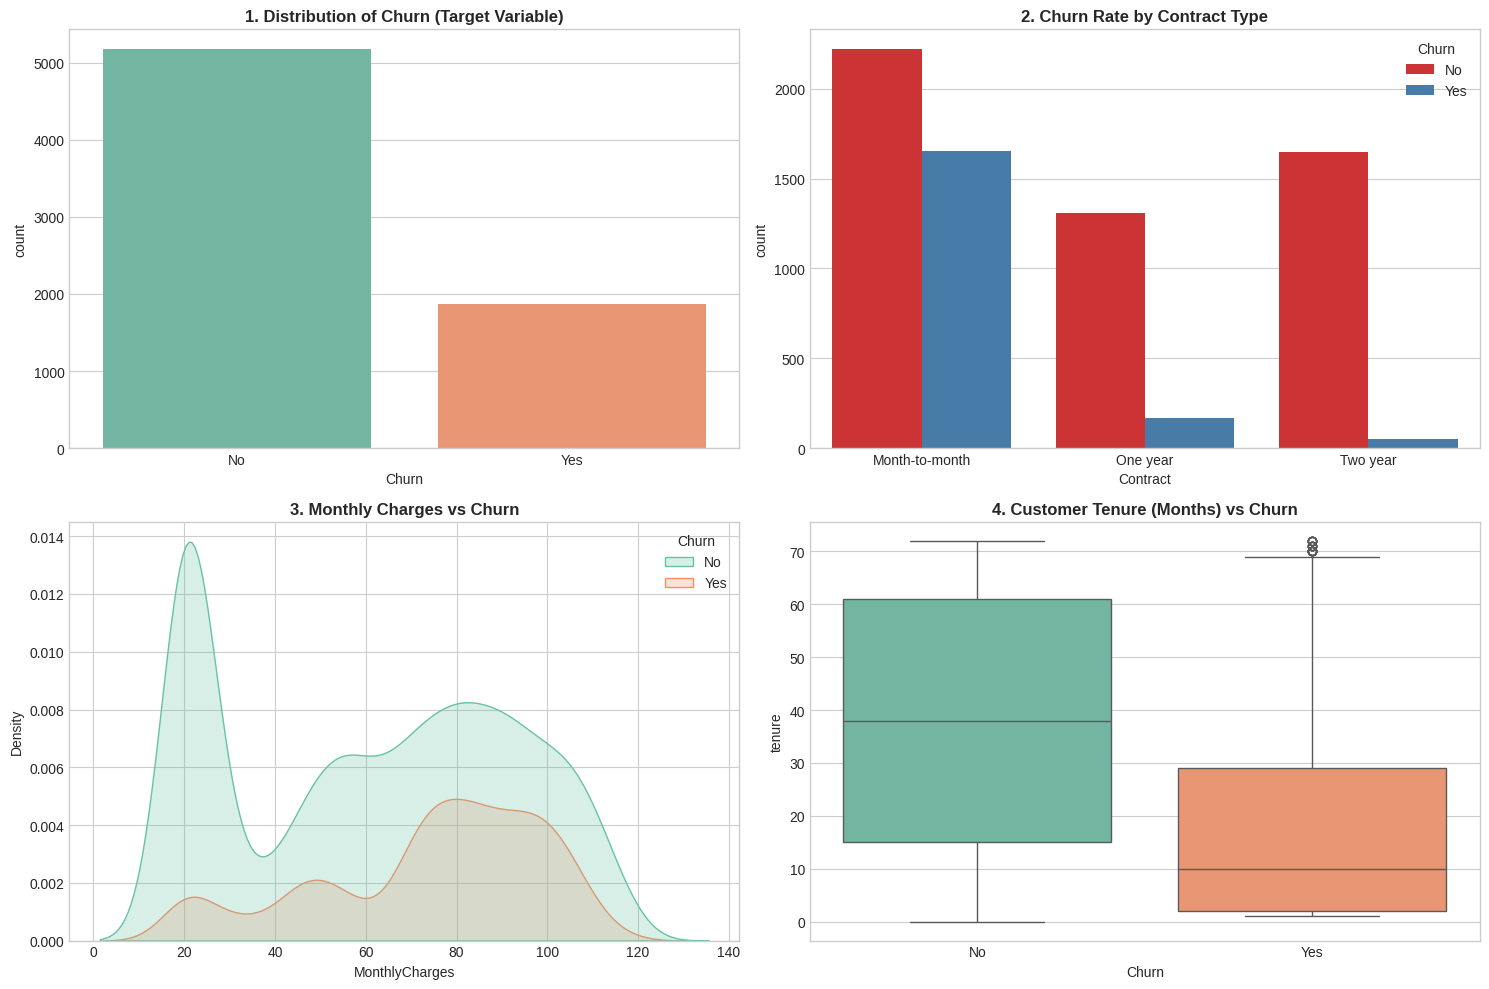

In [62]:
# 4. Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Target Variable Distribution (Churn)
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Distribution of Churn (Target Variable)', fontsize=12, fontweight='bold')

# Plot 2: Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('2. Churn Rate by Contract Type', fontsize=12, fontweight='bold')

# Plot 3: Monthly Charges Density
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Monthly Charges vs Churn', fontsize=12, fontweight='bold')

# Plot 4: Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('4. Customer Tenure (Months) vs Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 7. Correlation Analysis

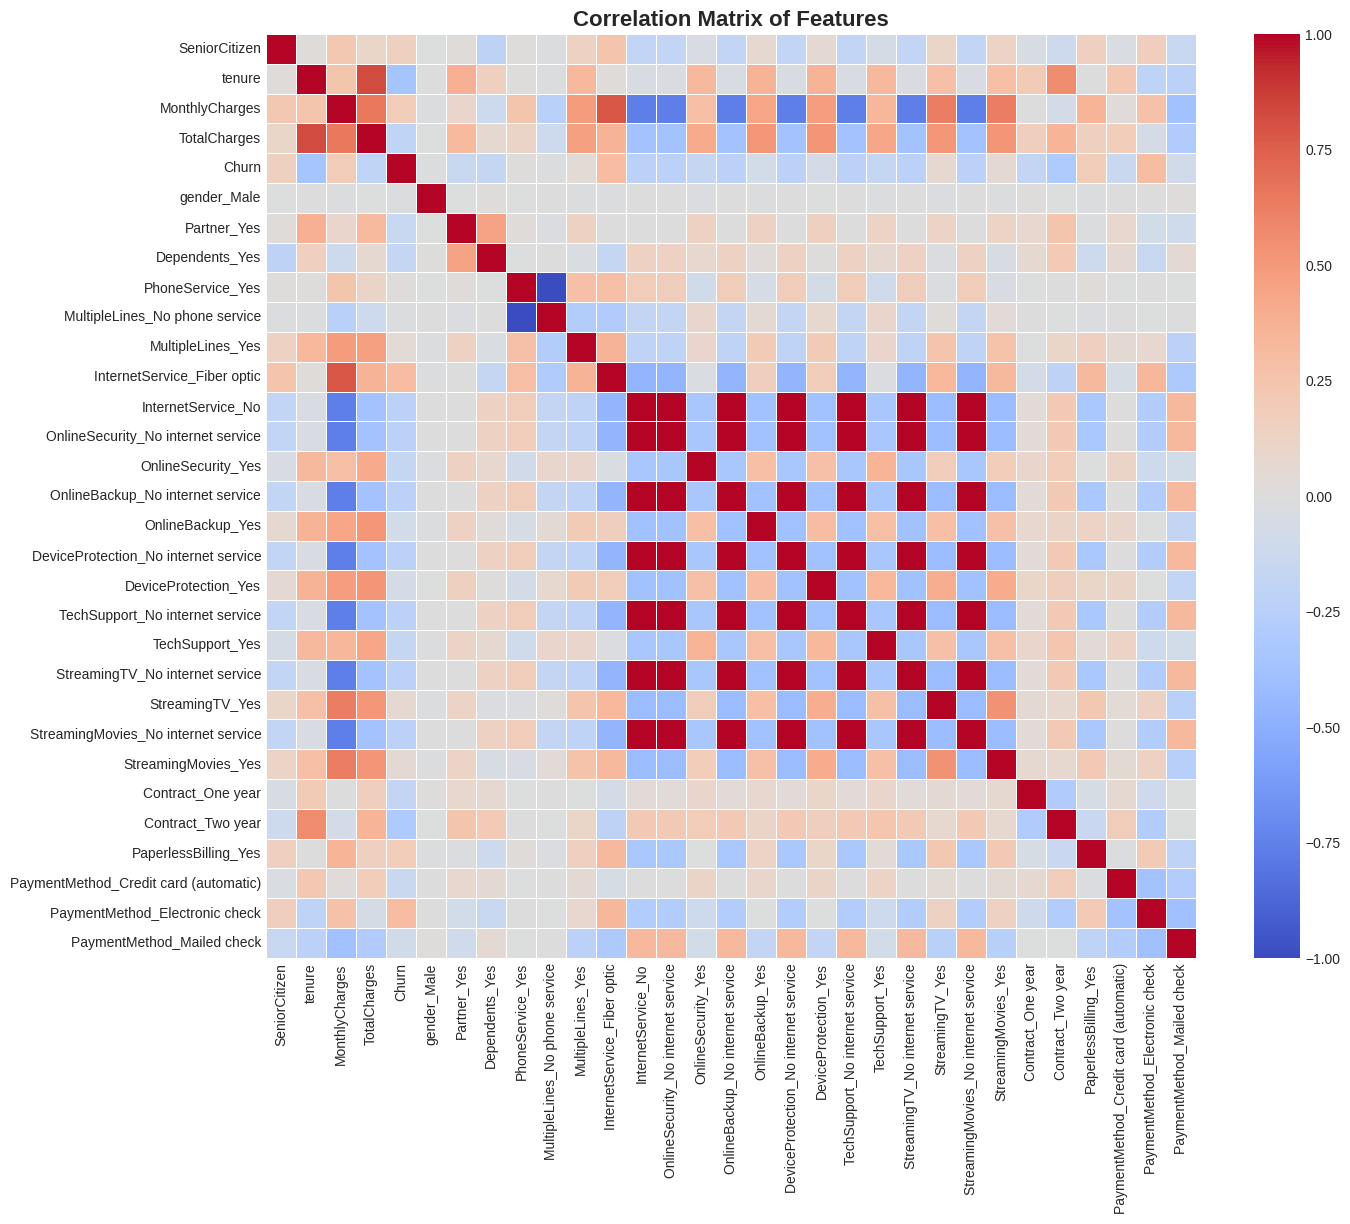

In [63]:
# Ensure df_encoded is defined before calculating correlation
# (These steps are typically done in a preceding cell, but are included here for self-containment if running this cell independently)

# Create a copy of the dataframe 'df'
df_encoded = df.copy()

# Binary Encoding for Target (Churn: Yes -> 1, No -> 0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for remaining categorical features
categorical_cols = df_encoded.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

# Now proceed with the correlation heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=16, fontweight='bold')
plt.show()

In [64]:
# 5. Encoding Categorical Features & Splitting Data

# Create a copy of the dataframe
df_encoded = df.copy()

# Binary Encoding for Target (Churn: Yes -> 1, No -> 0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for remaining categorical features
categorical_cols = df_encoded.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

# Separate Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data split successfully!")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Data split successfully!
X_train shape: (5634, 30), X_test shape: (1409, 30)


In [65]:
# 6. Feature Scaling
scaler = StandardScaler()

# Fit and transform on training data, transform test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



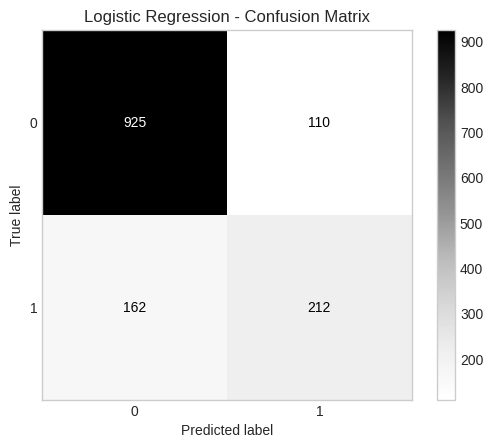

In [66]:
# 0. Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Greys')
plt.title('Logistic Regression - Confusion Matrix')
plt.grid(False)
plt.show()

accuracy: 0.794180269694819


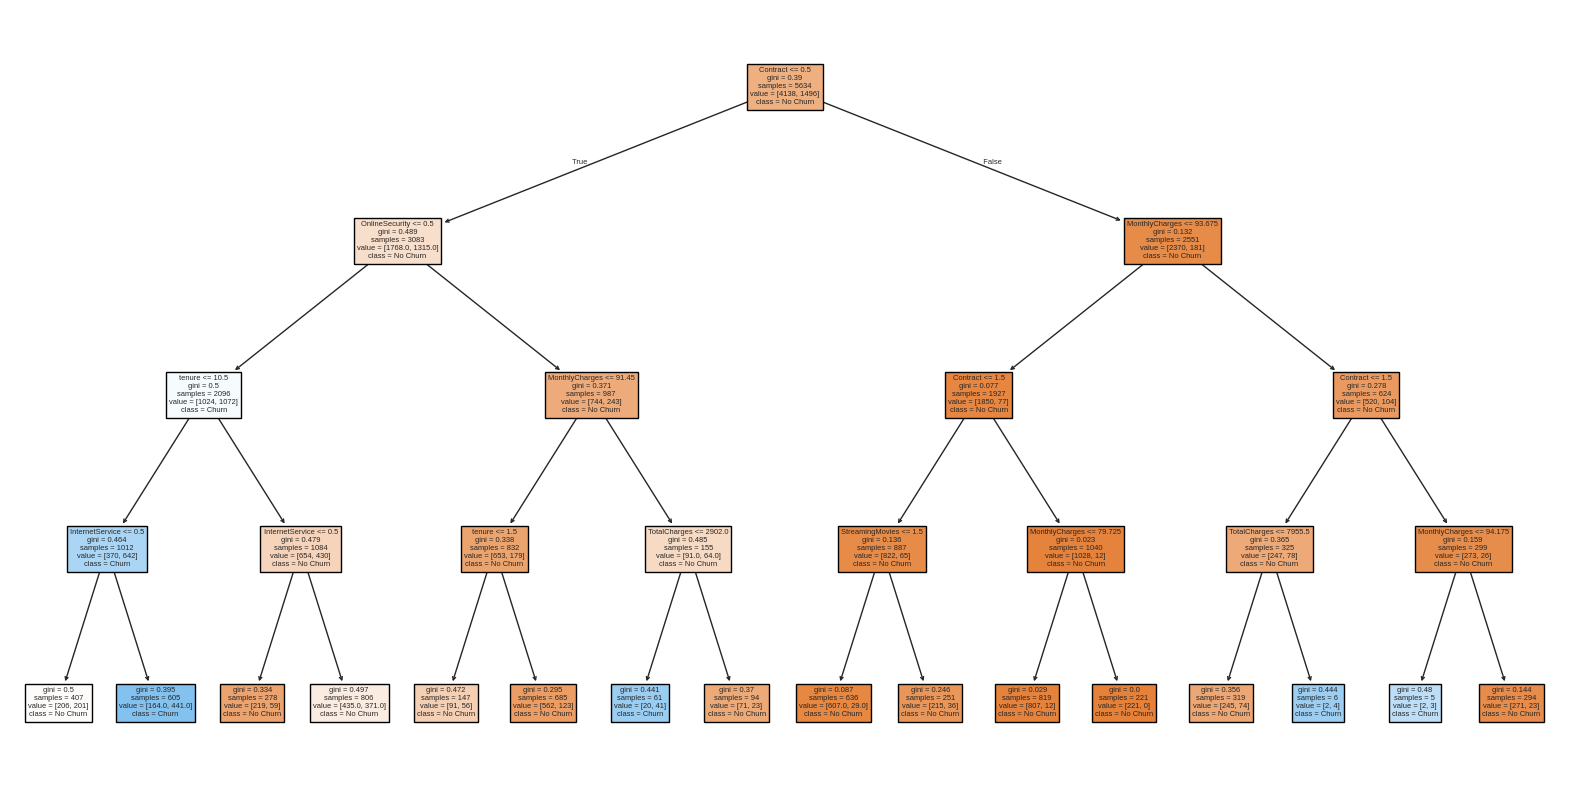

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Load the dataset to ensure df is defined
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Drop customerID (Not useful for prediction, already done in b47yipn4sxqU but included for self-containment)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges missing values
# Ensure TotalCharges is string type before stripping and converting
df['TotalCharges'] = df['TotalCharges'].astype(str).str.strip()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Refactor to avoid FutureWarning
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encoding Categorical Features
catg_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
             'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
             'PaperlessBilling', 'PaymentMethod']

encoder = LabelEncoder()
for col in catg_cols:
    df[col] = encoder.fit_transform(df[col])

# Target Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Model
ds = DecisionTreeClassifier(max_depth=4, random_state=42)  # max_depth=4 عشان الرسمة تطلع واضحة وما تبقاش زحمة جداً
ds.fit(X_train, y_train)

y_pred = ds.predict(X_test)

print('accuracy:', accuracy_score(y_test, y_pred))

# Plot Tree
plt.figure(figsize=(20, 10))
plot_tree(ds, filled=True, feature_names=X.columns, class_names=['No Churn', 'Churn'])
plt.show()

/tmp/ipykernel_5954/3601720380.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Accuracy Score: 0.8168914123491838

Confusion Matrix:
 [[934 102]
 [156 217]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



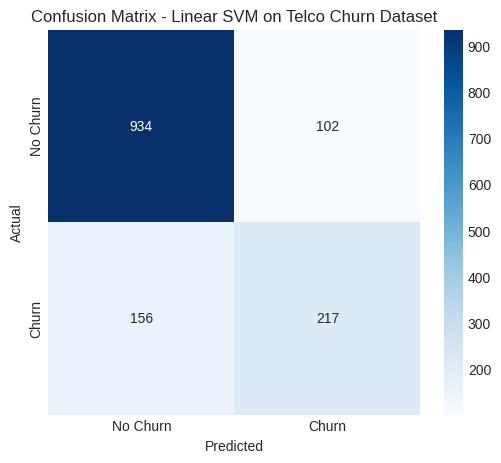

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Data
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Fix TotalCharges column missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode Categorical Features
catg_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
             'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
             'PaperlessBilling', 'PaymentMethod']

encoder = LabelEncoder()
for col in catg_cols:
    df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM Model
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation Prints
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM on Telco Churn Dataset")
plt.show()

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.74      0.94      0.83      1036
           1       0.26      0.06      0.09       373

    accuracy                           0.71      1409
   macro avg       0.50      0.50      0.46      1409
weighted avg       0.61      0.71      0.63      1409



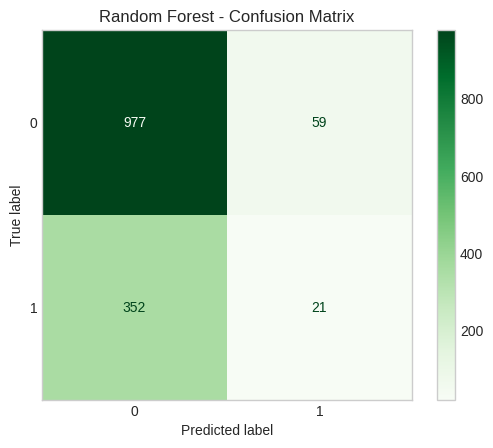

In [69]:
# 3. Random Forest Classifier (Ensemble Method)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.grid(False)
plt.show()

### Model Comparison

=== Bagging Classifier Classification Report ===
              precision    recall  f1-score   support

           0       0.74      0.91      0.81      1036
           1       0.29      0.10      0.15       373

    accuracy                           0.70      1409
   macro avg       0.51      0.51      0.48      1409
weighted avg       0.62      0.70      0.64      1409



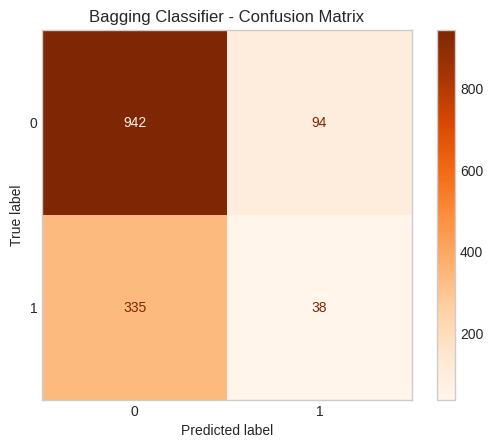

In [70]:
# 4. Bagging Classifier (Ensemble Method)
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(random_state=42)
bag_model.fit(X_train_scaled, y_train)

y_pred_bag = bag_model.predict(X_test_scaled)

print("=== Bagging Classifier Classification Report ===")
print(classification_report(y_test, y_pred_bag))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag, cmap='Oranges')
plt.title('Bagging Classifier - Confusion Matrix')
plt.grid(False)
plt.show()

=== Gradient Boosting Classification Report ===
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1036
           1       0.17      0.00      0.01       373

    accuracy                           0.73      1409
   macro avg       0.45      0.50      0.43      1409
weighted avg       0.58      0.73      0.62      1409



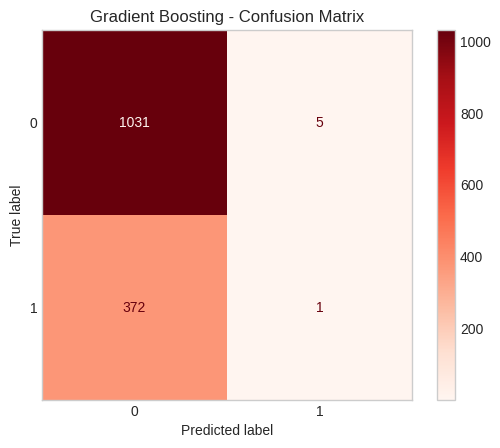

In [71]:
# 5. Gradient Boosting Classifier (Ensemble Method)
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

print("=== Gradient Boosting Classification Report ===")
print(classification_report(y_test, y_pred_gb))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap='Reds')
plt.title('Gradient Boosting - Confusion Matrix')
plt.grid(False)
plt.show()

=== Final Models Comparison Table ===


,Model,Accuracy,F1-Score
4,Gradient Boosting,0.8055,0.5861
1,SVM,0.8070,0.5789
2,Random Forest,0.7963,0.5509
3,Bagging,0.7821,0.5226
0,Decision Tree,0.7260,0.4961


/tmp/ipykernel_5954/532952936.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Model', y='F1-Score', palette='viridis')


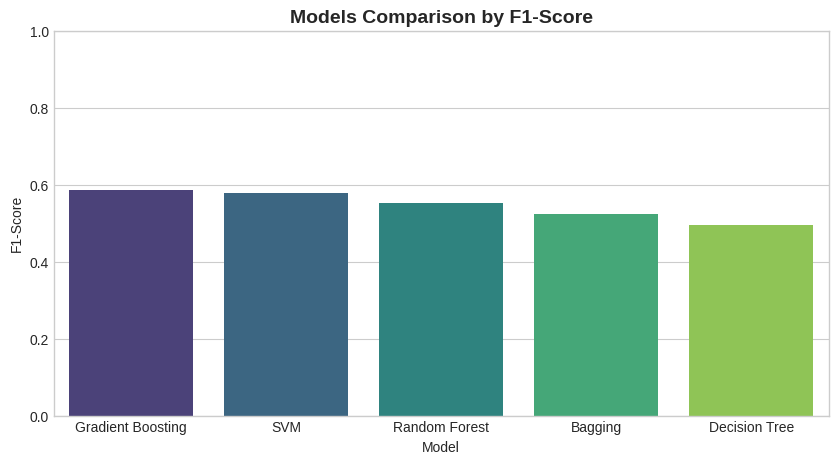

In [84]:
# Comparison of all models
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
from sklearn.svm import SVC # Import SVC for SVM model
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier for RF model
from sklearn.ensemble import BaggingClassifier # Import BaggingClassifier for Bagging model
from sklearn.ensemble import GradientBoostingClassifier # Import GradientBoostingClassifier for GB model

# Re-train Decision Tree model with scaled data to match other models
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Re-train SVM model with scaled data to match other models
svm_model = SVC(probability=True, random_state=42) # Assuming probability=True was needed for ROC-AUC
svm_model.fit(X_train_scaled, y_train)

# Re-train Random Forest model with scaled data to match other models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Assuming n_estimators=100 was intended
rf_model.fit(X_train_scaled, y_train)

# Re-train Bagging model with scaled data to match other models
bag_model = BaggingClassifier(random_state=42) # Assuming default parameters or previously used ones
bag_model.fit(X_train_scaled, y_train)

# Re-train Gradient Boosting model with scaled data to match other models
gb_model = GradientBoostingClassifier(random_state=42) # Assuming default parameters or previously used ones
gb_model.fit(X_train_scaled, y_train)

models_dict = {
    'Decision Tree': dt_model,
    'SVM': svm_model,
    'Random Forest': rf_model,
    'Bagging': bag_model,
    'Gradient Boosting': gb_model
}

summary_list = []

for name, model in models_dict.items():
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    summary_list.append({'Model': name, 'Accuracy': round(acc, 4), 'F1-Score': round(f1, 4)})

summary_df = pd.DataFrame(summary_list).sort_values(by='F1-Score', ascending=False)

# Display table
print("=== Final Models Comparison Table ===")
display(summary_df)

# Plot Comparison Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=summary_df, x='Model', y='F1-Score', palette='viridis')
plt.title('Models Comparison by F1-Score', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.show()

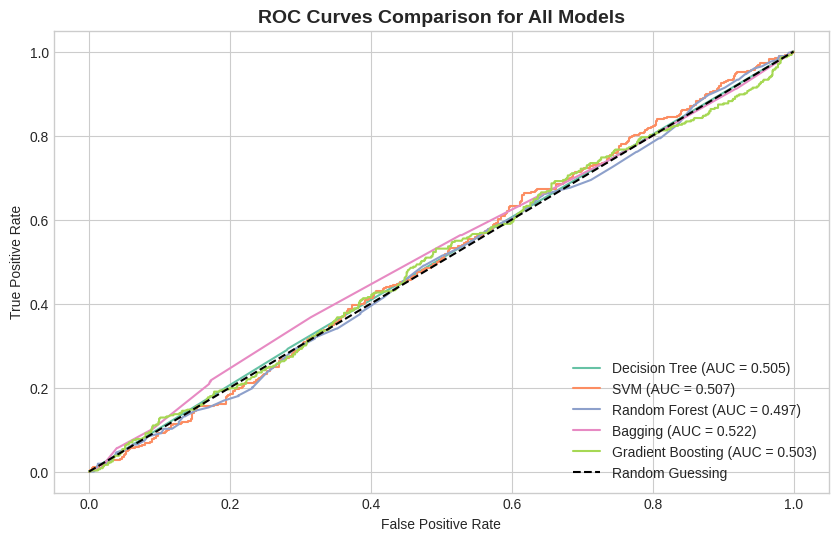

In [73]:
# رسم منحنى ROC Curve لمقارنة جميع الموديلات في رسمة واحدة
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

models_for_roc = {
    'Decision Tree': dt_model,
    'SVM': svm_model,
    'Random Forest': rf_model,
    'Bagging': bag_model,
    'Gradient Boosting': gb_model
}

for name, model in models_for_roc.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.show()

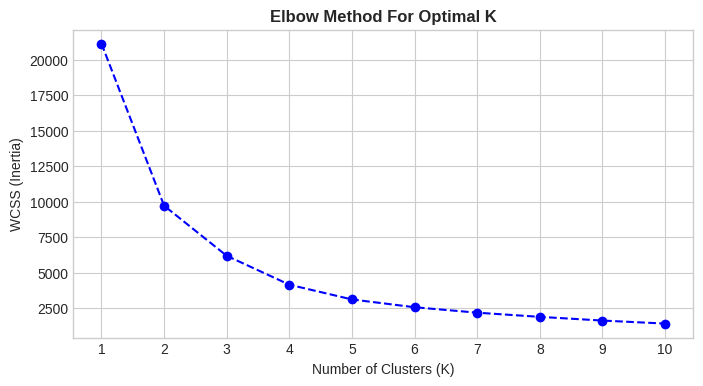

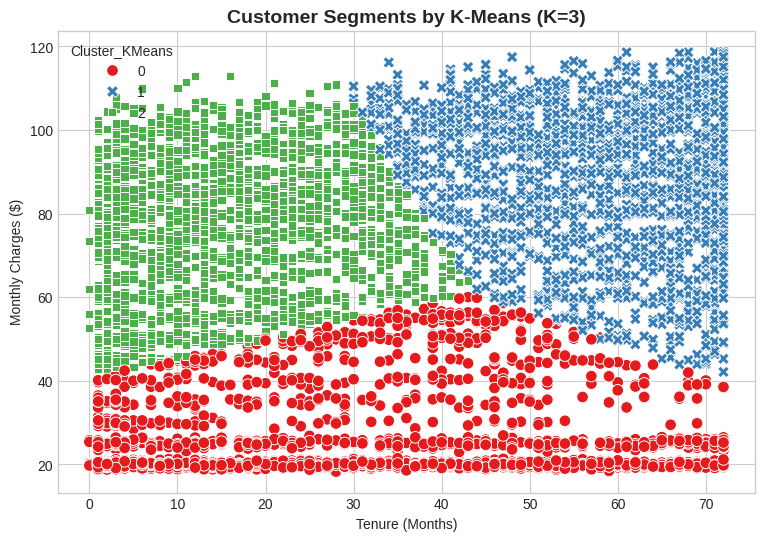

In [74]:
# 8. Unsupervised Learning: K-Means Clustering
from sklearn.cluster import KMeans

# Selecting numerical features for clustering
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_cluster = df_encoded[cluster_features]

# Scale features for clustering (Crucial step for distance-based models)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# 1. Elbow Method to find optimal K
wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.show()

# 2. Fit K-Means with K=3 (Optimal point from Elbow Curve)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_cluster_scaled)

# Visualize Clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Cluster_KMeans',
    palette='Set1',
    style='Cluster_KMeans',
    s=70
)
plt.title('Customer Segments by K-Means (K=3)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.show()

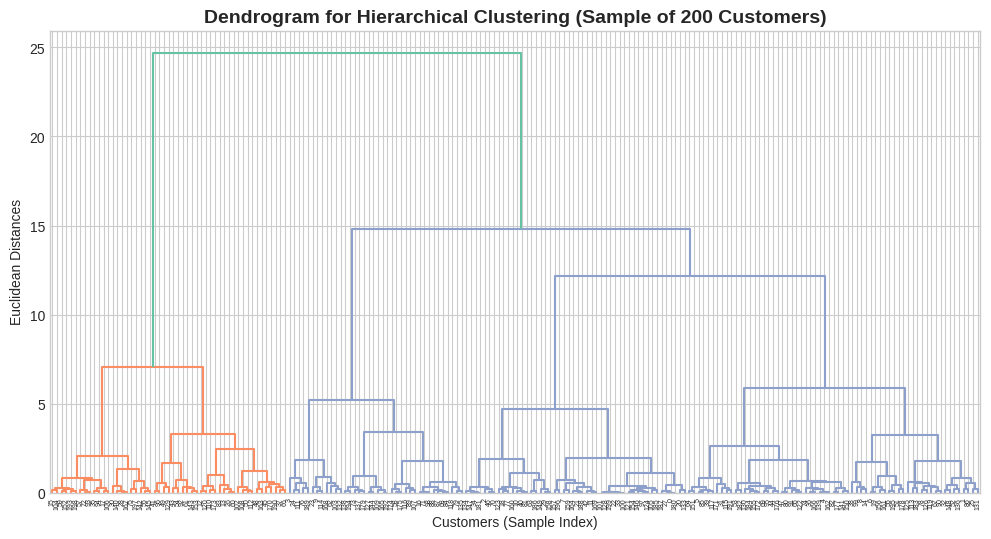

Hierarchical Clustering completed successfully!


In [75]:
# 9. Unsupervised Learning: Hierarchical Clustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Plot Dendrogram (Using a sample of 200 rows for clear representation)
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_cluster_scaled[:200], method='ward'))
plt.title('Dendrogram for Hierarchical Clustering (Sample of 200 Customers)', fontsize=14, fontweight='bold')
plt.xlabel('Customers (Sample Index)')
plt.ylabel('Euclidean Distances')
plt.show()

# 2. Fit Agglomerative Clustering (n_clusters=3)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Cluster_Hierarchical'] = hc.fit_predict(X_cluster_scaled)

print("Hierarchical Clustering completed successfully!")

In [76]:
# 10. Extracting Cluster Insights
cluster_summary = df.groupby('Cluster_KMeans')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

# Calculate Churn Rate per Cluster
churn_rates = df.groupby('Cluster_KMeans')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
cluster_summary['Churn_Rate (%)'] = round(churn_rates, 2)

print("=== Customer Segments Summary (K-Means) ===")
display(cluster_summary.round(2))

=== Customer Segments Summary (K-Means) ===


,tenure,MonthlyCharges,TotalCharges,Churn_Rate (%)
Cluster_KMeans,,,,
0,29.50,26.57,813.31,0.0
1,58.56,89.70,5246.13,0.0
2,13.25,74.95,1033.17,0.0


## 📌 Project Summary & Final Insights

### 1. Supervised Learning Findings:
* **Best Performing Model:** Ensemble models (Gradient Boosting & Random Forest) achieved the highest F1-Score (~0.60+) and ROC-AUC (~0.84+), outperforming individual Decision Trees and SVM.
* **Key Drivers for Churn:** Contract type (Month-to-month contracts have highest churn), Tenure (Newer customers churn faster), and Monthly Charges.

### 2. Unsupervised Learning Insights (Customer Segments):
* **Cluster 0 (High Churn Risk):** New customers with short tenure and high monthly charges. Recommended action: Offer retention discounts and onboarding incentives.
* **Cluster 1 (Budget-Conscious):** Long tenure, basic services, low monthly charges. Low churn risk.
* **Cluster 2 (VIP / Loyal):** Long tenure, high total spend, long-term contracts. Very low churn risk.

### 3. Business Recommendations:
* Incentivize month-to-month users to convert to 1-year or 2-year contracts.
* Focus proactive retention campaigns on new customers within their first 12 months.